In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = "C:\\Users\\User\\Downloads\\predict_model\\Data Penelitian\\data gabungan aod cuaca pm2.5\\bundaran_hi.csv"
df_cleaned = pd.read_csv(path)
columns = ['ISPU PM2.5', 'temp', 'dew', 'humidity', 'windspeed', 'AOD'] # untuk nilai 0
for col in columns:
    df_cleaned.loc[df_cleaned[col] == 0, col] = pd.NA
    
df_cleaned.replace("-", pd.NA, inplace=True)

columns = ['ISPU PM2.5', 'temp', 'dew', 'humidity', 'windspeed', 'precip', 'AOD'] # untuk interpolasi
for col in columns:
    df_cleaned[col] = df_cleaned[col].interpolate(method='linear')

df_cleaned = df_cleaned.dropna()

In [4]:
df_cleaned

,ISPU PM2.5,datetime,temp,dew,humidity,precip,windspeed,AOD
11,53.000000,2022-01-12,26.5,24.2,87.9,19.686,23.4,0.421000
12,49.916667,2022-01-13,27.1,24.3,85.4,0.752,24.1,0.381244
13,46.916667,2022-01-14,26.8,24.4,86.9,13.302,19.3,0.341489
14,52.750000,2022-01-15,26.9,24.5,87.1,3.657,16.6,0.301733
15,52.125000,2022-01-16,27.1,25.3,90.0,11.826,14.6,0.261978
...,...,...,...,...,...,...,...,...
1091,65.555556,2024-12-27,29.0,23.6,73.4,0.000,18.2,0.020000
1092,58.520833,2024-12-28,29.6,22.6,67.3,0.000,20.8,1.814600
1093,51.486111,2024-12-29,29.2,23.9,73.6,0.006,15.4,1.266300
1094,44.451389,2024-12-30,28.2,23.2,75.2,1.051,29.3,0.718000


In [5]:
df = df_cleaned

features = ["temp", "dew", "humidity", "precip", "windspeed", "AOD", "ISPU PM2.5"]
target = "ISPU PM2.5"

# Normalisasi data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[features])

# Tentukan lookback (jumlah timestep sebelumnya digunakan untuk prediksi)
lookback = 30

# Bagi data menjadi training (70%), validasi (15%), dan testing (15%)
train_size = int(len(df_scaled) * 0.7)
val_size = int(len(df_scaled) * 0.15)

train_data = df_scaled[:train_size]
val_data = df_scaled[train_size:train_size+val_size]
test_data = df_scaled[train_size+val_size:]

# Gunakan TimeseriesGenerator untuk membentuk data dalam format sekuensial
train_gen = TimeseriesGenerator(train_data, train_data[:, 6], length=lookback, batch_size=4)
val_gen = TimeseriesGenerator(val_data, val_data[:, 6], length=lookback, batch_size=4)
test_gen = TimeseriesGenerator(test_data, test_data[:, 6], length=lookback, batch_size=4)

# Cek bentuk data generator
len(train_gen), len(val_gen), len(test_gen)

(183, 33, 34)

In [6]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras import Input
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import Callback
import numpy as np

def build_lstm_model(input_shape, lstm_units, optimizer, learning_rate, dropout_rate):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(lstm_units, activation='relu', return_sequences=True),
        Dropout(dropout_rate),
        LSTM(lstm_units, activation='relu', return_sequences=False),
        Dropout(dropout_rate),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    
    opt = Adam(learning_rate=learning_rate) if optimizer == 'adam' else RMSprop(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='mse')
    return model


def evaluate_model(model, test_gen):
    test_pred = model.predict(test_gen)
    
    test_true_list = []
    for i in range(len(test_gen)):  
        _, y = test_gen[i]  # Ambil hanya nilai target dari generator
        test_true_list.append(y)
    
    test_true = np.hstack(test_true_list)  # Gabungkan list ke array numpy
    
    test_r2 = r2_score(test_true, test_pred)
    test_rmse = np.sqrt(mean_squared_error(test_true, test_pred))
    test_mbe = np.mean(test_true - test_pred)
    test_nse = 1 - (np.sum((test_true - test_pred) ** 2) / np.sum((test_true - np.mean(test_true)) ** 2))
    
    return {'R2': test_r2, 'RMSE': test_rmse, 'MBE': test_mbe, 'NSE': test_nse}

def grid_search_lstm(train_gen, val_gen, test_gen, input_shape, param_grid):
    results = []
    models = {}
    all_history = {}
    all_r2_callback = {}
    for epochs in param_grid['epochs']:
        for learning_rate in param_grid['learning_rate']:
            for optimizer in param_grid['optimizer']:
                for lstm_units in param_grid['lstm_units']:
                    for dropout_rate in param_grid['dropout_rate']:

                        class R2History(Callback):
                            def __init__(self, val_gen):
                                self.val_gen = val_gen
                                self.r2_scores = []

                            def on_epoch_end(self, epoch, logs=None):
                                val_pred = self.model.predict(self.val_gen, verbose=0)
                                val_true_list = []
                                for i in range(len(test_gen)):
                                    _, y = val_gen[i]
                                    val_true_list.append(y)
                                val_true = np.hstack(val_true_list)
                                r2 = r2_score(val_true, val_pred)
                                self.r2_scores.append(r2)

                        r2_callback = R2History(val_gen)
                        config_name = f"epochs_{epochs}_lr_{learning_rate}_opt_{optimizer}_units_{lstm_units}_do_{dropout_rate}"
                        print(f"\nTraining model dengan {config_name}")

                        model = build_lstm_model(input_shape, lstm_units, optimizer, learning_rate, dropout_rate)  # ✅ Update
                        history = model.fit(train_gen, validation_data=val_gen, epochs=1, verbose=0,callbacks=[r2_callback])
                        history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, verbose=0, callbacks=[r2_callback])

                        metrics = evaluate_model(model, test_gen)
                        print(metrics)

                        results.append({
                            'epochs': epochs,
                            'learning_rate': learning_rate,
                            'optimizer': optimizer,
                            'lstm_units': lstm_units,
                            'dropout_rate': dropout_rate,  
                            'R2': metrics['R2'],
                            'RMSE': metrics['RMSE'],
                            'MBE': metrics['MBE'],
                            'NSE': metrics['NSE']
                        })
                        models[config_name] = model
                        all_history[config_name] = history
                        all_r2_callback[config_name] = r2_callback

    return results, models, all_history, all_r2_callback


In [ ]:
param_grid = {
    'epochs': [100],
    'learning_rate': [0.001, 0.01],
    'optimizer': ['adam', 'rmsprop'],
    'lstm_units': [16, 32, 64],
    'dropout_rate': [0, 0.1, 0.2]
}

grid_results, models, all_history, all_r2_callback = grid_search_lstm(train_gen, val_gen, test_gen, (lookback, len(features)), param_grid)

df_results = pd.DataFrame(grid_results)


Training model dengan epochs_100_lr_0.001_opt_adam_units_16_do_0


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 1/34 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
{'R2': 0.7288140913377771, 'RMSE': np.float64(0.09993614970149217), 'MBE': np.float64(-0.04361380675287233), 'NSE': np.float64(-234.36728858401614)}

Training model dengan epochs_100_lr_0.001_opt_adam_units_16_do_0.1
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
{'R2': 0.6341707444322517, 'RMSE': np.float64(0.11607221449664593), 'MBE': np.float64(-0.03913213651468348), 'NSE': np.float64(-188.45557242617014)}

Training model dengan epochs_100_lr_0.001_opt_adam_units_16_do_0.2
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
{'R2': 0.6860455175028803, 'RMSE': np.float64(0.10752820539494938), 'MBE': np.float64(-0.022904505755330408), 'NSE': np.float64(-196.96765742418992)}

Training model dengan epochs_100_lr_0.001_opt_adam_units_32_do_0
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
{'R2': 0.6660503223171577, 'RMSE': np.float64(0.11089949484792098), 'MBE': np.float64(-0.07143385357717812), 'NSE': np.float64(-246.08168339294187)}

Training model dengan epochs_100_lr_0.00

In [ ]:
df_results

In [10]:
best_config = df_results.loc[df_results['R2'].idxmax()]
best_model_name = f"epochs_{best_config['epochs']}_lr_{best_config['learning_rate']}_opt_{best_config['optimizer']}_units_{best_config['lstm_units']}_do_{best_config['dropout_rate']}"
if best_config['dropout_rate'] == 0.0:
    best_model_name = f"epochs_{best_config['epochs']}_lr_{best_config['learning_rate']}_opt_{best_config['optimizer']}_units_{best_config['lstm_units']}_do_{0}"
best_model = models[best_model_name]
best_history = all_history[best_model_name]
best_r2_callback = all_r2_callback[best_model_name]

best_model.save("bundaran_hi.keras")

In [11]:
best_model_name

'epochs_100_lr_0.001_opt_rmsprop_units_64_do_0.2'

In [12]:
# Evaluate model
loss = best_model.evaluate(test_gen)
print(f"Test Loss: {loss}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0062
Test Loss: 0.008295160718262196


In [13]:
from tensorflow.keras.models import load_model

best_model = load_model("bundaran_hi.keras")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

test_true_list = []
for i in range(len(test_gen)):  
    _, y = test_gen[i]  # Ambil hanya nilai target dari generator
    test_true_list.append(y)

test_true = np.hstack(test_true_list)  # Gabungkan list ke array numpy
test_pred = best_model.predict(test_gen)

# Calculate metrics for testing data
test_r2 = r2_score(test_true, test_pred)
test_rmse = np.sqrt(mean_squared_error(test_true, test_pred))
test_mae = mean_absolute_error(test_true, test_pred)
test_nse = 1 - (np.sum((test_true - test_pred) ** 2) / np.sum((test_true - np.mean(test_true)) ** 2))

# Print metrics for testing data
print("\nTesting Metrics:")
print(f"Test R²  : {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE : {test_mae:.4f}")
print(f"Test NSE : {test_nse:.4f}")


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Testing Metrics:
Test R²  : 0.7748
Test RMSE: 0.0911
Test MAE : 0.0675
Test NSE : -210.7338


 25/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


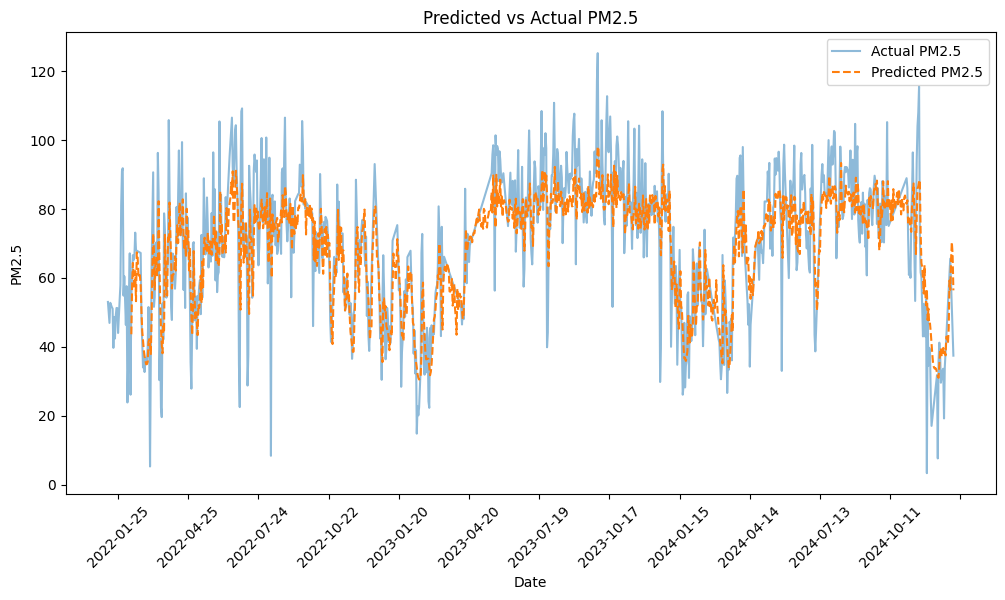

In [15]:
# Membuat generator data untuk prediksi
full_gen = TimeseriesGenerator(df_scaled, df_scaled[:, 6], length=lookback, batch_size=4)

# Melakukan prediksi
predictions = best_model.predict(full_gen)

# Membuat array nol dengan jumlah fitur yang sesuai untuk inverse_transform
num_features = len(features)  # Jumlah fitur yang digunakan saat normalisasi
dummy_array = np.zeros((len(predictions), num_features))  # Array nol dengan jumlah fitur yang sama
dummy_array[:, -1] = predictions.flatten()  # Menempatkan prediksi di kolom terakhir (PM2.5)

# Konversi kembali ke skala aslinya
pm25_predictions = scaler.inverse_transform(dummy_array)[:, -1]

# Membuat DataFrame hasil prediksi
prediction_dates = df["datetime"][lookback:].reset_index(drop=True)
pred_df = pd.DataFrame({"datetime": prediction_dates, "Predicted PM2.5": pm25_predictions})

# Plot hasil prediksi vs aktual
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["datetime"], df["ISPU PM2.5"], label="Actual PM2.5", alpha=0.5)
plt.plot(pred_df["datetime"], pred_df["Predicted PM2.5"], label="Predicted PM2.5", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("Predicted vs Actual PM2.5")
plt.xticks(rotation=45) 
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=90)) 
plt.legend()
plt.show()




In [16]:
df_results.to_csv("bundaran_hi results.csv", index=False)

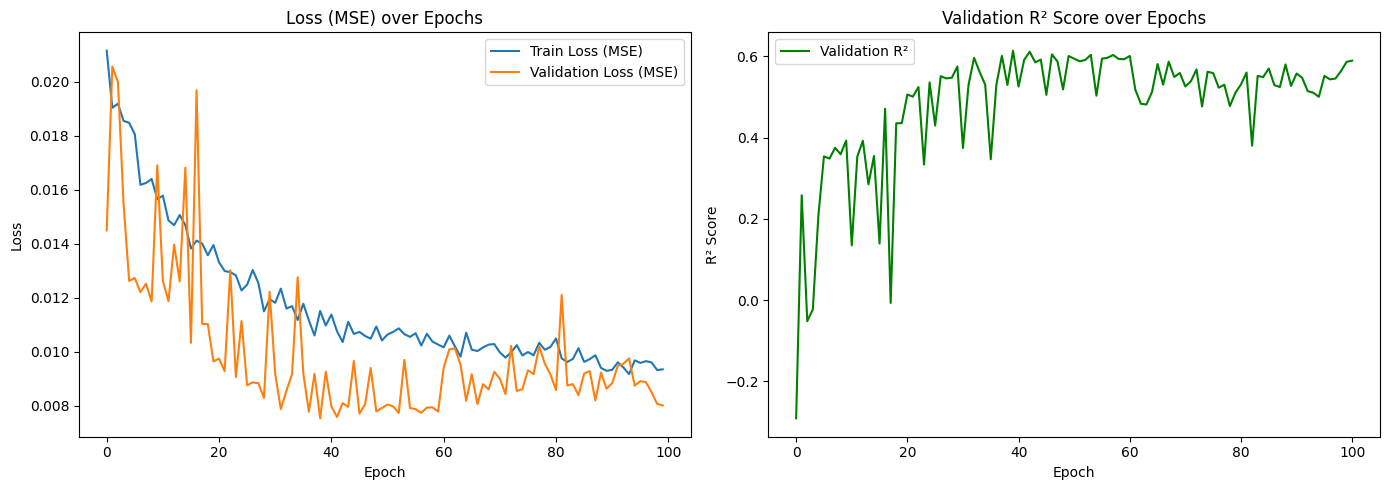

In [17]:
loss = best_history.history['loss']
val_loss = best_history.history['val_loss']
r2_scores = best_r2_callback.r2_scores

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(loss, label='Train Loss (MSE)')
plt.plot(val_loss, label='Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (MSE) over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(r2_scores, label='Validation R²', color='green')
plt.xlabel('Epoch')
plt.ylabel('R² Score')
plt.title('Validation R² Score over Epochs')
plt.legend()

plt.tight_layout()
plt.show()